### Importing the required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,confusion_matrix

import warnings
warnings.filterwarnings('ignore')

### Loading and understanding the dataset

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Here we observe that total charges dtype is object let's change it.

In [8]:
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')

In [9]:
# Check for duplicated entries
df.duplicated().sum()

0

In [10]:
# Check for null values
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Here TotalCharges column has 11 missing values. Let's check this data.

#### Handling null values

In [11]:
df[np.isnan(df['TotalCharges'])]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


- Even though the MonthlyCharges column is not empty,the tenure colum is 0.
- Let's delete the rows with missing values in Tenure columns since there are only 11 rows and deleting them will not affect the data.

In [12]:
df = df.drop(df[df['tenure'] == 0].index, axis=0)

Filling missing values in TotalCharges column with the mean of TotalCharges values.

In [13]:
df = df.fillna(df['TotalCharges'].mean())

In [14]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Exploratory Data Analysis

In [15]:
# Removing redundant columns
df = df.drop('customerID',axis=1)

In [16]:
# Stats summary of numerical data
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [17]:
# Stats summary of categorical data
df.describe(include='O')

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,3549,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365,5163


#### Data Visualization

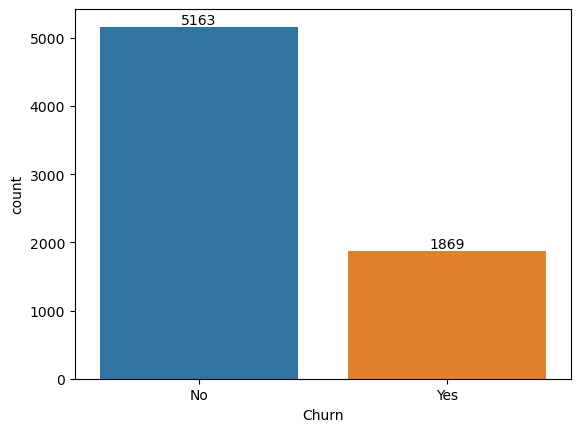

In [18]:
# Distribution of target column
ax = sns.countplot(x=df['Churn'])
ax.bar_label(ax.containers[0])
plt.show()

The count plot shows that the number of churned customers is significantly lower than the number of non-churned customers, indicating a class imbalance in the dataset.

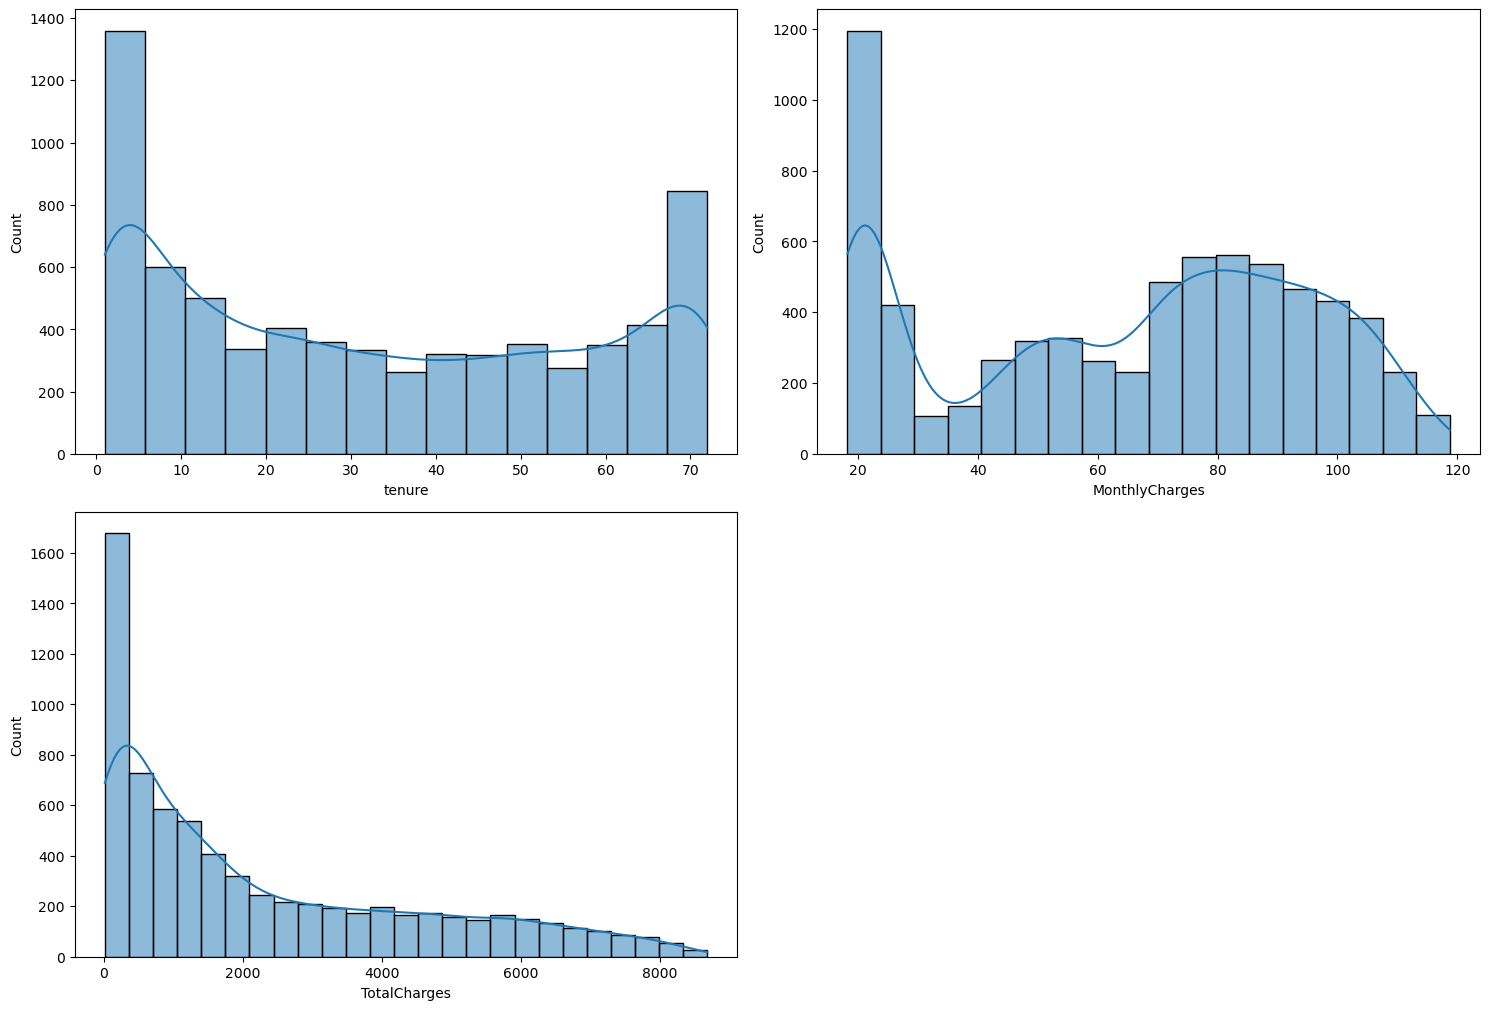

In [19]:
# Distribution of numerical columns
plt.figure(figsize=(15,50))
num_cols = ['tenure','MonthlyCharges','TotalCharges']
for i,col in enumerate(num_cols):
    plt.subplot(10,2,i+1)
    sns.histplot(x=df[col],kde=True)
plt.tight_layout()
plt.show()

##### Relationship between Features and Target

<Axes: xlabel='Churn', ylabel='tenure'>

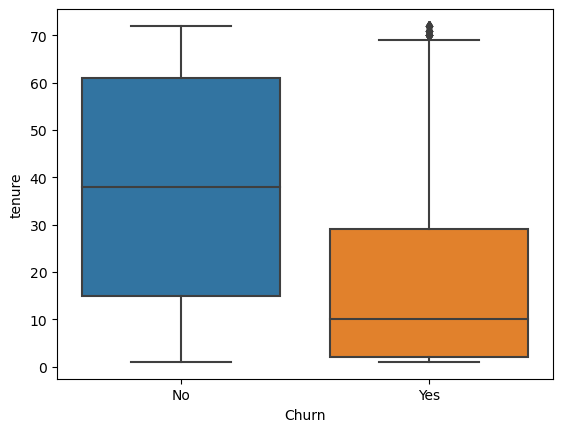

In [20]:
# tenure vs Churn
sns.boxplot(x=df['Churn'],y=df['tenure'])

Customers with a longer tenure are less likely to churn.

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

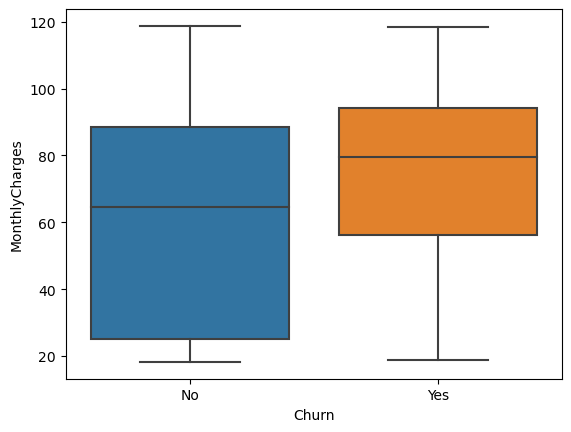

In [21]:
# MonthlyCharges vs Churn
sns.boxplot(x=df['Churn'],y=df['MonthlyCharges'])

Higher monthly charges might drive churn due to cost dissatisfaction.

<Axes: xlabel='Churn', ylabel='TotalCharges'>

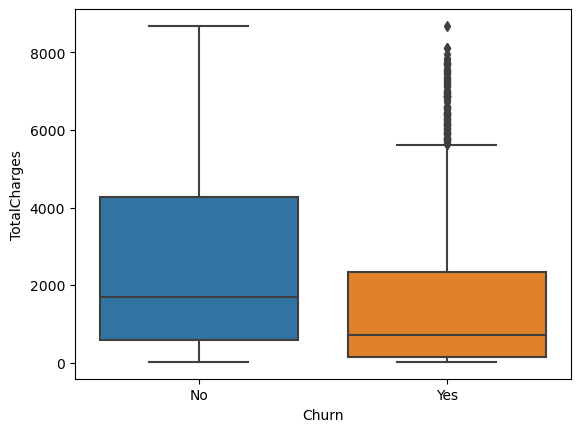

In [22]:
# TotalCharges vs Churn
sns.boxplot(x=df['Churn'],y=df['TotalCharges'])

Customers with higher total charges (indicating long-term customers) were less likely to churn.

<Axes: xlabel='Partner', ylabel='count'>

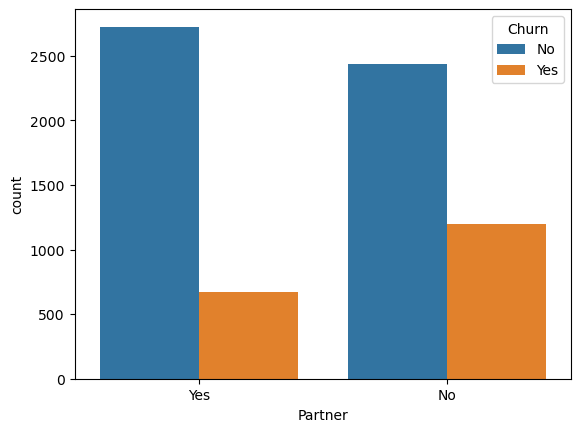

In [23]:
# Partner vs Churn
sns.countplot(x=df['Partner'],hue=df['Churn'])

Customers without a partner are more likely to churn compared to those with a partner.

<Axes: xlabel='InternetService', ylabel='count'>

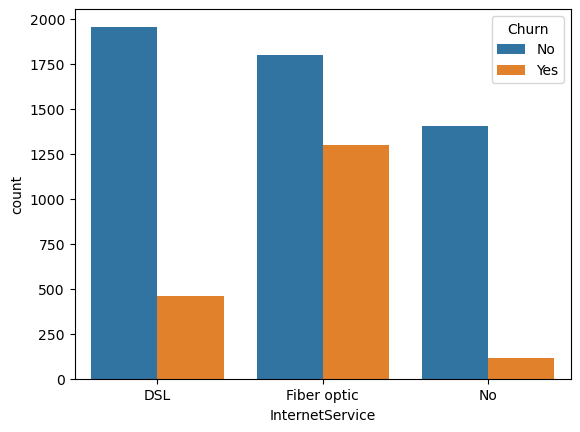

In [24]:
# InternetService vs Churn
sns.countplot(x=df['InternetService'],hue=df['Churn'])

Customers using Fiber Optic internet had the highest churn rate compared to those using DSL or those with no internet service.

<Axes: xlabel='OnlineSecurity', ylabel='count'>

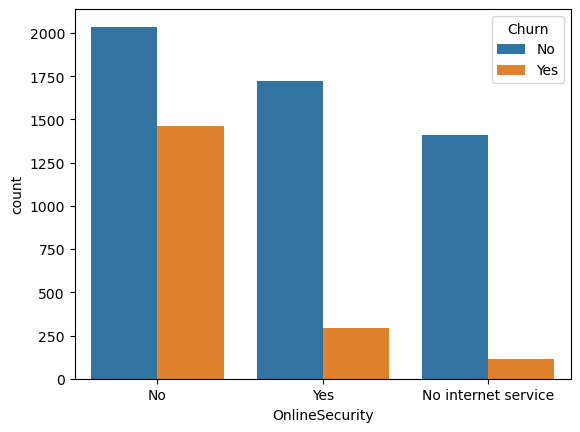

In [25]:
# OnlineSecurity vs Churn
sns.countplot(x=df['OnlineSecurity'],hue=df['Churn'])

Customers with Online Security or Tech Support were significantly less likely to churn.

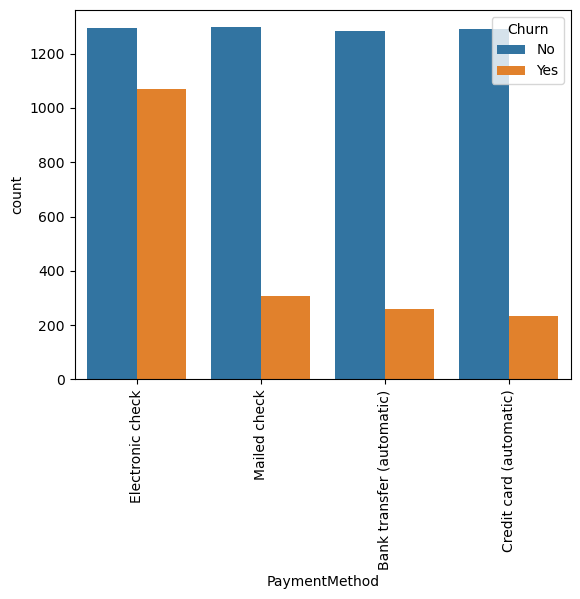

In [26]:
# PaymentMethod vs Churn
sns.countplot(x=df['PaymentMethod'],hue=df['Churn'])
plt.xticks(rotation='vertical')
plt.show()

Customers using electronic checks have the highest churn.

<Axes: xlabel='Contract', ylabel='count'>

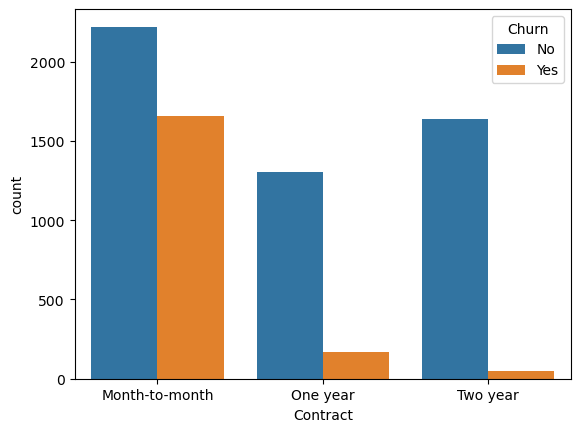

In [27]:
# Contract vs Churn
sns.countplot(x=df['Contract'],hue=df['Churn'])

Customers with a month-to-month contract are more likely to churn compared to those with longer-term contracts.

##### Relationship between Features

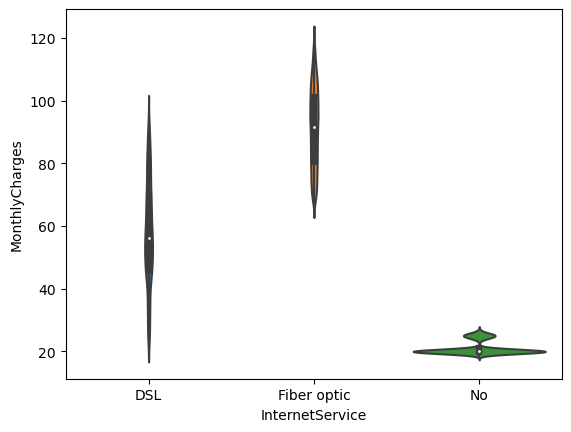

In [28]:
# InternetService and MonthlyCharges 
sns.violinplot(x='InternetService', y='MonthlyCharges', data=df)
plt.show()

Fiber optic internet service is more expensive compared to other types of internet services.

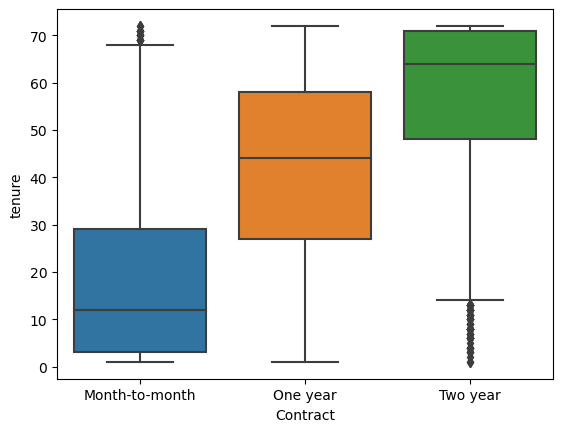

In [29]:
# Tenure Distribution by contract type
sns.boxplot(x='Contract', y='tenure', data=df)
plt.show()

Customers with a 2-year contract tend to have a longer tenure.

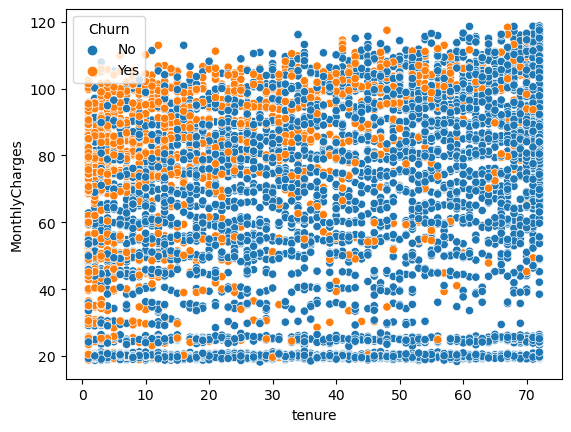

In [30]:
# Monthly charges based on tenure
sns.scatterplot(x='tenure',y='MonthlyCharges',data=df,hue='Churn')
plt.show()

As tenure increases, MonthlyCharges tend to vary, with some customers having higher or lower charges.

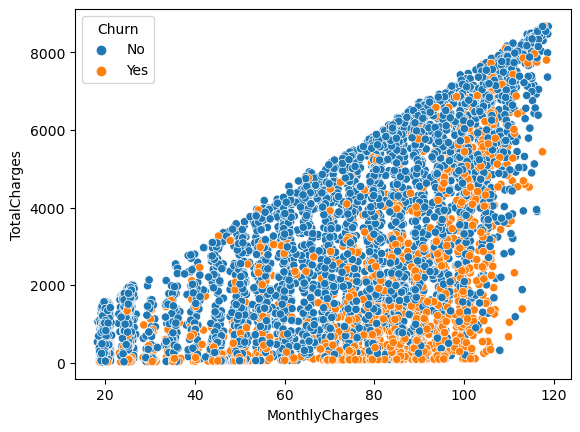

In [31]:
# Monthly charges and Totalcharges
sns.scatterplot(x='MonthlyCharges', y='TotalCharges', data=df,hue='Churn')
plt.show()

As MonthlyCharges increase, TotalCharges also tend to increase.

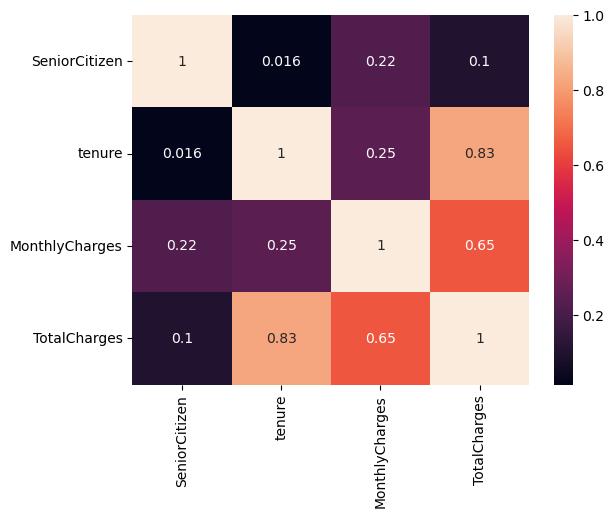

In [32]:
# Correlation heatmap
sns.heatmap(data=df.corr(),annot=True)
plt.show()

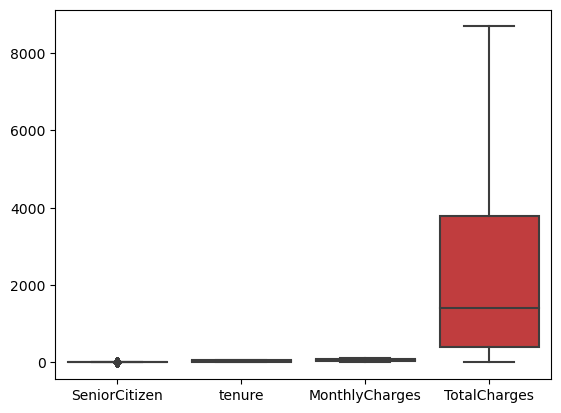

In [33]:
# Check for outliers
sns.boxplot(data=df)
plt.show()

### Data Preprocessing

#### Encoding Categorical data

In [34]:
# Label Encoding
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
encoder = LabelEncoder()
for column in cat_cols:
    df[column] = encoder.fit_transform(df[column])

In [35]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [36]:
# Feature Separartion
X = df.drop('Churn',axis=1)
y = df.Churn

#### Train Test Split

In [37]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#### Handling class imbalance
- Here the dataset shows a class imbalance, with fewer customers having churned compared to those who stayed. To address this imbalance, techniques like SMOTE (Synthetic Minority Over-sampling Technique) are applied to generate synthetic samples for the minority class, ensuring a more balanced distribution and improving the model's ability to accurately predict churned customers.

In [38]:
smote = SMOTE()
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [39]:
y_train_smote.value_counts()

1    4130
0    4130
Name: Churn, dtype: int64

### Model Training and Evaluation

In [40]:
def evaluate_model(model):
    
    # Training Model
    model.fit(X_train_smote,y_train_smote)
    print(f'Training Accuracy:{model.score(X_train_smote,y_train_smote)}')
    
    # Predictions
    y_pred = model.predict(X_test)
    report = classification_report(y_test,y_pred)
    
    # Displaying Results
    print(f'Classification Report:\n{report}')
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f'Confusion Matrix for {type(model).__name__}')
    plt.show()
    
    # Kde Plot
    sns.kdeplot(y_test, label='Actual',color='b')
    sns.kdeplot(y_pred, label='Predicted',color='r')
    plt.title(f'Actual vs Fitted values for {type(model).__name__}')
    plt.legend()

#### Decision Tree

Training Accuracy:0.9983050847457627
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.79      0.81      1033
           1       0.48      0.55      0.52       374

    accuracy                           0.72      1407
   macro avg       0.66      0.67      0.66      1407
weighted avg       0.74      0.72      0.73      1407



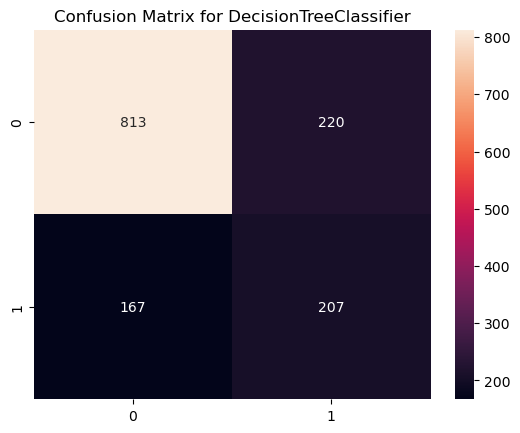

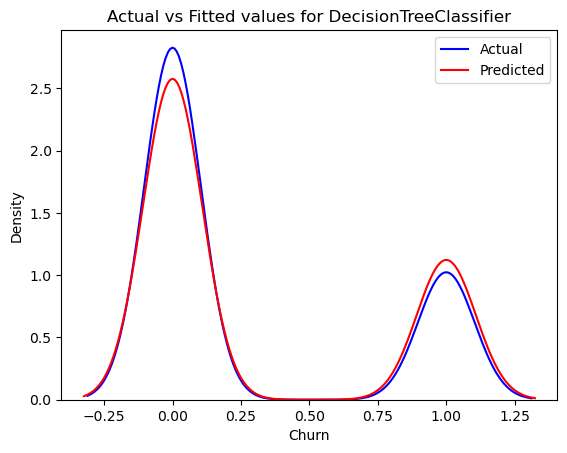

In [41]:
evaluate_model(DecisionTreeClassifier())

#### Random Forest Classifier

Training Accuracy:0.9983050847457627
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1033
           1       0.55      0.56      0.56       374

    accuracy                           0.76      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.76      0.76      0.76      1407



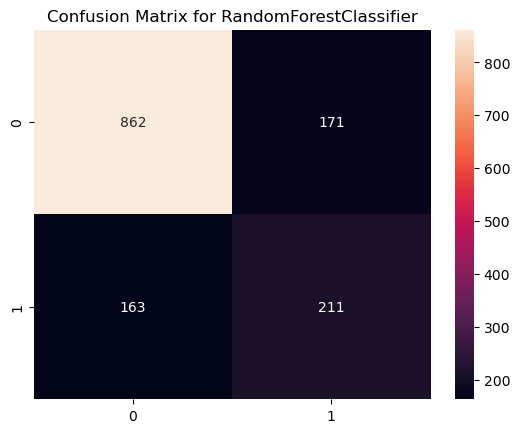

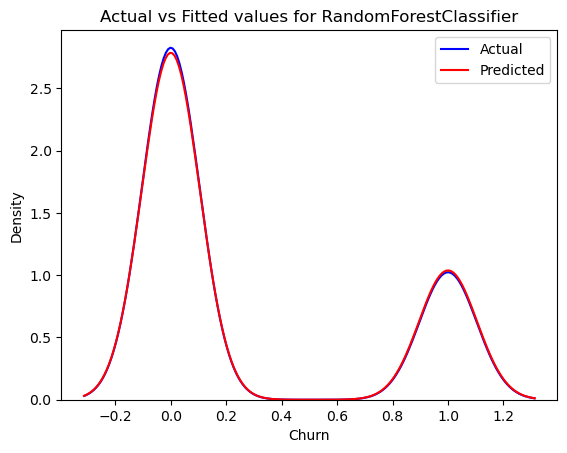

In [42]:
evaluate_model(RandomForestClassifier())

#### XgBoost

Training Accuracy:0.9561743341404358
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1033
           1       0.53      0.57      0.55       374

    accuracy                           0.75      1407
   macro avg       0.68      0.69      0.69      1407
weighted avg       0.76      0.75      0.75      1407



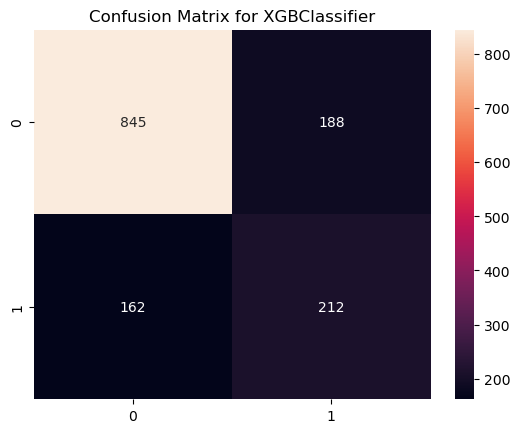

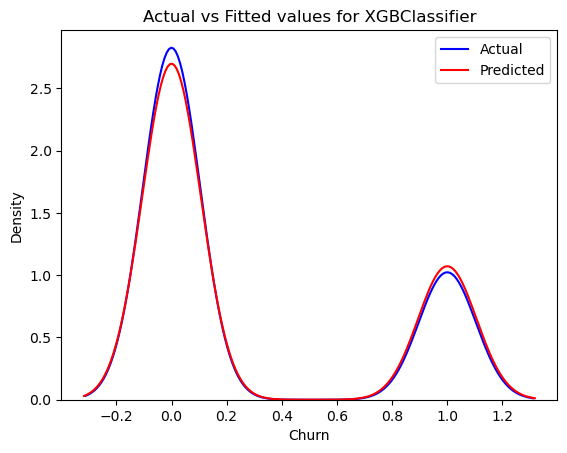

In [43]:
evaluate_model(XGBClassifier())

From the evaluation of the models, the **Random Forest Classifier** emerged as the best-performing model, achieving a accuracy score of 77% and a well-balanced precision, recall, and F1-score.Therefore, it is the most suitable choice for accurately predicting customer churn.

However,the **Random Forest** model showed signs of overfitting, as it achieved high accuracy on the training data but less on the test data. To address this, hyperparameter tuning was performing using RandomSearchCV to optimize the model's parameters, reduce overfitting, and improve its generalization on unseen data.

### Hyperparameter tuning

In [44]:
# Define random grid
random_grid = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(10, 100),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None],
}

In [48]:
# Define the model
rfc = RandomForestClassifier()

# Define the RandomizedSearchCV
rfc_model = RandomizedSearchCV(estimator=rfc,param_distributions=random_grid,cv=3,scoring='f1',verbose=2,n_jobs=-1,n_iter=50,random_state=42)
rfc_model.fit(X_train_smote, y_train_smote)

# Get the best parameters 
print("Best Parameters:", rfc_model.best_params_)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'max_depth': 65, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 179}


In [49]:
# Predictions after tuning the model
y_pred = rfc_model.predict(X_test)
print(f'Classifcation Report:\n{classification_report(y_test,y_pred)}')

Classifcation Report:
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1033
           1       0.56      0.57      0.57       374

    accuracy                           0.76      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.77      0.76      0.77      1407



After tuning the model, the recall and F1-score for class 1 improved, indicating better performance in identifying the minority class. Although the overall accuracy decreased to 76%, the increase in recall and F1-score suggests that the model is now better at correctly identifying churned customers,making it more effective for handling class imbalance.

### Feature Importance

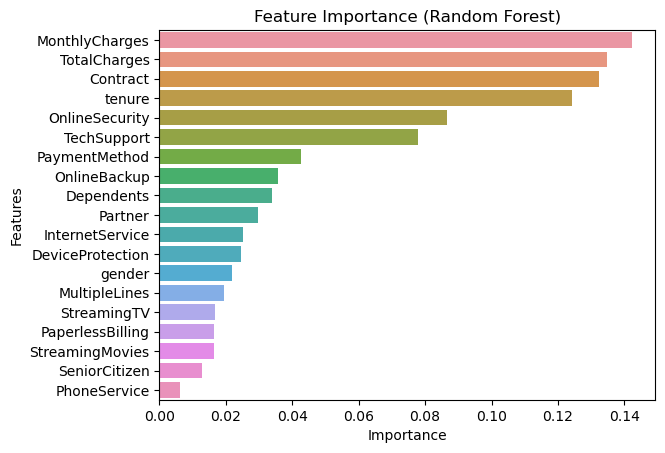

In [53]:
best_rfc = rfc_model.best_estimator_
feature_df = pd.DataFrame({'Features': X_train.columns, 'Importance': best_rfc.feature_importances_}).sort_values('Importance', ascending=False)

# Plot feature importance
sns.barplot(data=feature_df, x='Importance', y='Features')
plt.title('Feature Importance (Random Forest)')
plt.show()

From the above Feature Importance plot, it is clear that **MonthlyCharges, TotalCharges, Contract, Tenure, OnlineSecurity, and TechSupport** are the most important features for predicting customer churn. Therefore, the company should focus on these factors to reduce customer churn.